# Example of PSD Comparison
This notebook demonstrates how to open a raw data file and create a composite waterfall plot showing all psds.

## Imports

In [14]:
from nasctn_sea_visualization import *
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np



## Data Ingest
Change the path to reflect your local copy  or NIST PDR location (https://data.nist.gov/od/ds/mds2-4214/Raw%20Data/2025-08-14_HU.zip)

In [2]:
day_block_path = r"C:\Users\sandersa\Box\SEA-DATA\Raw Data\2025-08-14_HU.zip"
day_block = DayBlock(file_path = day_block_path)

In [3]:
# here are the percentiles that are available
print(day_block.psd_statistics)

['max', 'mean', 'median', '25th_percentile', '75th_percentile', '90th_percentile', '95th_percentile', '99th_percentile', '99.9th_percentile', '99.99th_percentile']


In [8]:
# we use this list to order the presentation of percentiles
percentiles = ['max', 'mean', 'median', '99.99th_percentile','99.9th_percentile',
               '99th_percentile','95th_percentile','90th_percentile','75th_percentile','25th_percentile']
psds = []
for percentile in percentiles:
    psd = day_block.get_day_psd(capture_statistic=percentile)
    psds.append(psd)

## Plotting

In [15]:
# calculate global colorbar limits
vmin = np.min([psd.min() for psd in psds])
vmax = np.max([psd.max() for psd in psds])

Text(0, 0.5, 'Time (UTC)')

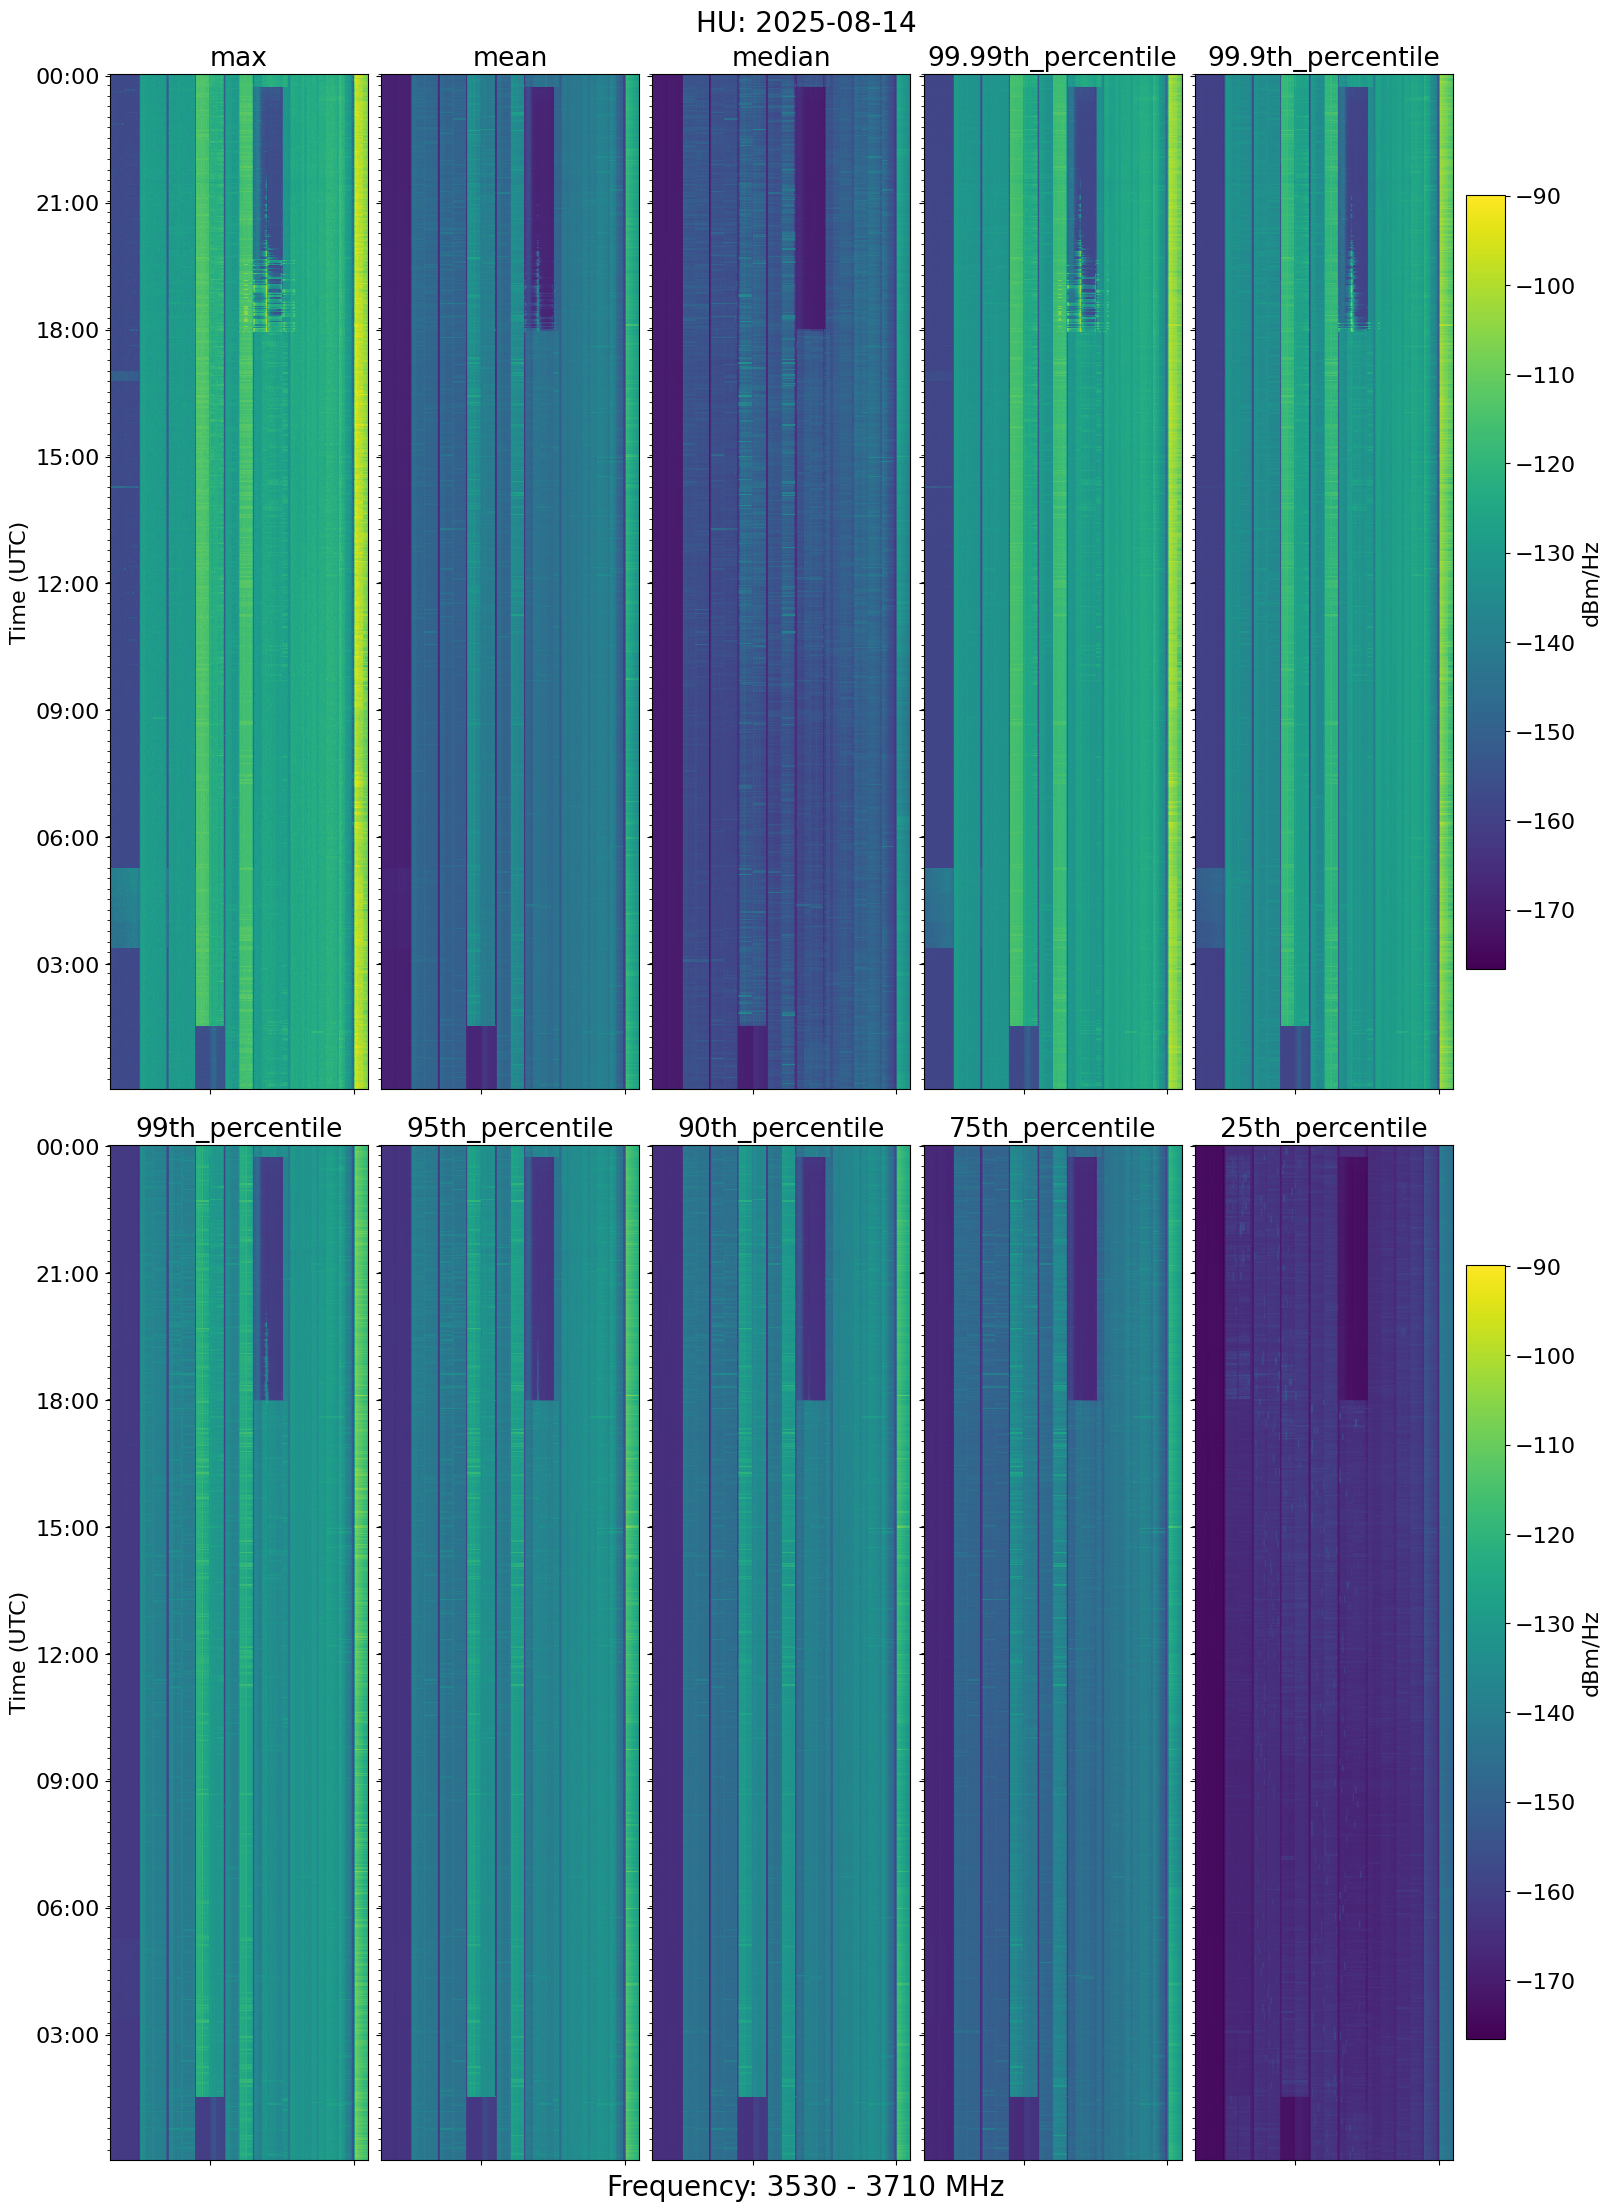

In [23]:

# a time axis formatter for better presentation
date_formatter = mdates.DateFormatter("%H:%M")
minor_locator = mdates.MinuteLocator(interval = 15)
major_locator = mdates.HourLocator(interval=3)

plt.rcParams.update({'font.size': 16}) 
# Now we have 10 percentiles
figure,axes = plt.subplots(nrows = 2,ncols = 5, figsize = (16,22),sharey=True,sharex=True,layout='constrained')
axes = axes.flatten()
for ax_index,ax in enumerate(axes):
    psd  = psds[ax_index]
    if ax_index == 4:
        colormesh = ax.pcolormesh(1e-6*psd.columns.astype(float),psd.index,psd,vmin=vmin,vmax=vmax)
    elif ax_index==9:
        colormesh_2 = ax.pcolormesh(1e-6*psd.columns.astype(float),psd.index,psd,vmin=vmin,vmax=vmax)
    else:
        ax.pcolormesh(1e-6*psd.columns.astype(float),psd.index,psd,vmin=vmin,vmax=vmax)
    ax.set_title(percentiles[ax_index])
    ax.yaxis.set_minor_locator(minor_locator)
    ax.yaxis.set_major_locator(major_locator)
    ax.yaxis.set_major_formatter(date_formatter)
    ax.tick_params(axis='x', labelbottom=False, labeltop=False)


figure.colorbar(colormesh,ax=axes[4],label="dBm/Hz", orientation='vertical')
figure.colorbar(colormesh_2,ax=axes[9],label="dBm/Hz", orientation='vertical')

figure.supxlabel("Frequency: 3530 - 3710 MHz",fontsize = 20)
figure.suptitle("HU: 2025-08-14",fontsize = 20)
axes[0].set_ylabel("Time (UTC)")
axes[5].set_ylabel("Time (UTC)")



# Watermark

In [21]:
%load_ext watermark
%watermark
%watermark --iversions

Last updated: 2026-09-20T11:16:52.146220-06:00

Python implementation: CPython
Python version       : 3.9.23
IPython version      : 8.18.1

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 197 Stepping 2, GenuineIntel
CPU cores   : 16
Architecture: 64bit

dateutil                : 2.9.0.post0
hvplot                  : 0.8.0
json                    : 2.0.9
matplotlib              : 3.9.4
nasctn_sea_visualization: 0.1.6
numpy                   : 1.26.4
pandas                  : 1.5.3
re                      : 2.2.1
scipy                   : 1.11.0
sea_ingest              : 1.0.1
seaborn                 : 0.12.0

